# Multi-Camera Bird's-Eye-View Perception: Lift-Splat with a DINOv2 Backbone (nuScenes)

A camera-only BEV network built module by module in PyTorch, following **Lift-Splat-Shoot** (Philion & Fidler, ECCV 2020). The image
encoder is swapped for a **DINOv2 ViT-S/14** foundation model:

| Stage | What it does | Output shape (batch 2) |
|---|---|---|
| Data | 6 synchronised nuScenes cameras, resized 1600×900 → 448×224, ImageNet-normalised | `[2, 6, 3, 224, 448]` |
| Backbone | DINOv2 ViT-S/14 patch tokens → 16×32 feature map per camera | `[2, 6, 384, 16, 32]` |
| Lift | 1×1 conv → 41 depth bins (4–45 m) + 64 context channels; softmax(depth) ⊗ context | `[2, 6, 41, 64, 16, 32]` |
| Geometry | pinhole un-projection with each camera's real, rescaled intrinsics → ego frame via calibrated extrinsics | `[2, 6, 41, 16, 32, 3]` |
| Splat | sum-pool all 6 × 41 × 16 × 32 frustum points into a 200×200 grid at 0.5 m (100 m × 100 m) | `[2, 64, 200, 200]` |
| Heads | semantic occupancy (3 classes) + detection heatmap (objectness, class, x, y, z, w, l, yaw) | `[2, 3, 200, 200]`, `[2, 8, 200, 200]` |

**Status: architecture and geometry are complete; the network has not been trained yet.** The BEV maps below come from randomly initialised
heads. They validate the tensor plumbing and camera geometry, not learned perception. Outputs are from the original run on nuScenes v1.0-mini.

## 1 · Data: six synchronised cameras

Each nuScenes *sample* is a keyframe with one image per camera. The dataset stacks the six views in a fixed order (front-left, front, front-right,
back-right, back, back-left) into one tensor.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
from nuscenes.nuscenes import NuScenes

class NuScenesMultiCamDataset(Dataset):
    def __init__(self, nusc, transform=None):
        self.nusc = nusc
        self.samples = self.nusc.sample
        
        self.cams = [
            'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
            'CAM_BACK_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT'
        ]
        
        # DINOv2/ViT requires images to be normalized to ImageNet standards
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 448)), 
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        imgs = []
        
        # Loop through the 360-degree array
        for cam in self.cams:
            cam_data = self.nusc.get('sample_data', sample['data'][cam])
            img_path = os.path.join(self.nusc.dataroot, cam_data['filename'])
            
            # Open, format, and transform
            img = Image.open(img_path).convert('RGB')
            img = self.transform(img)
            imgs.append(img)
            
        # Stack the 6 independent camera images into a single Tensor
        # Resulting shape: (Num_Cameras, Channels, Height, Width)
        multi_cam_tensor = torch.stack(imgs, dim=0)
        
        return multi_cam_tensor

if __name__ == '__main__':
    print("Loading nuScenes...")
    nusc = NuScenes(version='v1.0-mini', dataroot='./data/sets/nuscenes', verbose=False)
    
    dataset = NuScenesMultiCamDataset(nusc)
    
    # Wrap it in a PyTorch DataLoader (Simulating a training batch)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)
    
    batch = next(iter(dataloader))
    
    print(f"Batch Tensor Shape: {batch.shape}")
    print("Format Breakdown: [Batch_Size, Cameras, Channels, Height, Width]")

Loading nuScenes...
Batch Tensor Shape: torch.Size([2, 6, 3, 224, 448])
Format Breakdown: [Batch_Size, Cameras, Channels, Height, Width]


## 2 · Backbone: DINOv2 ViT-S/14

All six views go through the backbone as one batch of 12 images. The normalised patch tokens (`x_norm_patchtokens`) are reshaped back into a
16×32 grid (224/14 × 448/14) with 384 channels per patch.

In [2]:
import torch
import torch.nn as nn

class MultiCamDINOv2Backbone(nn.Module):
    def __init__(self, model_name='dinov2_vits14'):
        super().__init__()
        print(f"Loading pre-trained foundation model: {model_name}...")
        
        # vits14 corresponds to a Vision Transformer Small with a patch size of 14x14
        self.backbone = torch.hub.load('facebookresearch/dinov2', model_name)
        
        # DINOv2 ViT-S outputs 384 channels per token/patch
        self.feature_dim = 384 
        
        self.backbone.head = nn.Identity()

    def forward(self, x):
        # Input shape: [B, N_Cams, C, H, W]
        B, N_Cams, C, H, W = x.shape
        
        # 1. Collapse Batch and Camera dimensions for parallel GPU processing
        x = x.view(B * N_Cams, C, H, W)
        
        # 2. Extract patches. DINOv2 downsamples images by its patch size (14)
        patch_h = H // 14
        patch_w = W // 14
        
        # Output patch tokens shape: [B * N_Cams, Num_Patches, Feature_Dim]
        features = self.backbone.forward_features(x)["x_norm_patchtokens"]
        
        # 3. Reshape patch tokens back into a structured 2D spatial feature grid
        features = features.permute(0, 2, 1) # [B * N_Cams, Feature_Dim, Num_Patches]
        features = features.view(B * N_Cams, self.feature_dim, patch_h, patch_w)
        
        # 4. Uncollapse Batch and Camera dimensions back to the original layout
        features = features.view(B, N_Cams, self.feature_dim, patch_h, patch_w)
        
        return features

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MultiCamDINOv2Backbone().to(device)
    model.eval()
    
    # [Batch Size = 2, 6 Cameras, 3 RGB Channels, Height = 224, Width = 448]
    dummy_input = torch.randn(2, 6, 3, 224, 448).to(device)
    
    with torch.no_grad():
        output_features = model(dummy_input)
        
    print(f"Output Feature Tensor Shape: {output_features.shape}")
    print("Format Breakdown: [Batch_Size, Cameras, Feature_Channels, Feature_Height, Feature_Width]")

Loading pre-trained foundation model: dinov2_vits14...


Output Feature Tensor Shape: torch.Size([2, 6, 384, 16, 32])
Format Breakdown: [Batch_Size, Cameras, Feature_Channels, Feature_Height, Feature_Width]


## 3 · Lift: per-pixel depth distribution × context features

A 1×1 convolution predicts, for each feature pixel, a categorical distribution over 41 depth bins (4–45 m, 1 m apart) plus a 64-d context vector.
Their outer product places the feature along the camera ray in proportion to the depth probability, giving a "frustum" of features.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LiftModule(nn.Module):
    def __init__(self, in_channels=384, out_channels=64, depth_bins=41):
        super().__init__()
        self.depth_bins = depth_bins
        self.out_channels = out_channels

        # A 1x1 Convolution to compress DINO's 384 channels.
        # We output 'out_channels' (for the actual semantic features) 
        # PLUS 'depth_bins' (for the depth probability predictions).
        self.cam_encode = nn.Conv2d(in_channels, out_channels + depth_bins, kernel_size=1)

    def forward(self, x):
        # Input x shape: [B, N_Cams, C, H, W] -> [2, 6, 384, 16, 32]
        B, N, C, H, W = x.shape

        x = x.view(B * N, C, H, W)

        # 2. Pass through the encoder
        x = self.cam_encode(x) # New Shape: [B*N, 64 + 41, 16, 32]

        # 3. Split the output into depth logits and semantic context features
        depth = x[:, :self.depth_bins, :, :]        # [B*N, 41, 16, 32]
        context = x[:, self.depth_bins:, :, :]      # [B*N, 64, 16, 32]

        # 4. Softmax the depth. 
        depth = F.softmax(depth, dim=1)

        # --- THE LIFT OPERATION ---
        # We perform an outer product between the depth probabilities and the context features.
        # If the network is 90% sure a pixel is at bin 10, it places 90% of the feature vector at bin 10.
        depth = depth.unsqueeze(2)      # [B*N, 41, 1, 16, 32]
        context = context.unsqueeze(1)  # [B*N, 1, 64, 16, 32]
        
        # Multiply to create the 3D Feature Frustum
        frustum_features = depth * context # Shape: [B*N, 41, 64, 16, 32]

        # 5. Uncollapse back to multiple cameras
        frustum_features = frustum_features.view(B, N, self.depth_bins, self.out_channels, H, W)

        return frustum_features

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    lift_net = LiftModule().to(device)
    
    dummy_dino_features = torch.randn(2, 6, 384, 16, 32).to(device)
    
    frustum3d = lift_net(dummy_dino_features)
    
    print(f"Output 3D Frustum Shape: {frustum3d.shape}")
    print("Format Breakdown: [Batch, Cameras, Depth_Bins, Feature_Channels, Height, Width]")

Output 3D Frustum Shape: torch.Size([2, 6, 41, 64, 16, 32])
Format Breakdown: [Batch, Cameras, Depth_Bins, Feature_Channels, Height, Width]


## 4 · Splat: voxel (pillar) pooling into the BEV grid

Every frustum point carries an ego-frame (x, y, z). Points are binned at 0.5 m into a 200×200 grid centred on the ego vehicle, and their features
are **summed per cell with a single `scatter_add_`** on the GPU. Height is collapsed, which gives pillar pooling.

In [4]:
import torch
import torch.nn as nn

class SplatModule(nn.Module):
    def __init__(self, bev_resolution=0.5, bev_size=(200, 200), feature_channels=64):
        super().__init__()
        # bev_resolution: 0.5 meters per grid cell
        # bev_size: 200x200 grid 
        self.bev_resolution = bev_resolution
        self.bev_size = bev_size
        self.channels = feature_channels

    def forward(self, frustum_features, ego_coordinates):
        """
        frustum_features: [B, N, D, C, H, W] (The output from Lift)
        ego_coordinates: [B, N, D, H, W, 3]  (The physical X, Y, Z location of every point)
        """
        B, N, D, C, H, W = frustum_features.shape

        # 1. Flatten the 6 cameras, depth bins, and spatial dimensions into one massive point cloud
        # Features: [Batch, Total_Points, Channels]
        features = frustum_features.permute(0, 1, 2, 4, 5, 3).reshape(B, -1, C) 
        
        # Coordinates: [Batch, Total_Points, 3] (X, Y, Z)
        coords = ego_coordinates.reshape(B, -1, 3) 

        # Initialize an empty, blank Bird's-Eye View grid (like an empty canvas)
        # Shape: [Batch, Channels, BEV_Y, BEV_X]
        bev_grid = torch.zeros(B, self.channels, self.bev_size[0], self.bev_size[1], device=features.device)

        # Iterate through the batch to map points to the grid
        for b in range(B):
            batch_coords = coords[b]     # [Total_Points, 3]
            batch_features = features[b] # [Total_Points, 64]

            # 2. Convert physical meters (X, Y) into discrete grid indices
            # Example: 10.5 meters / 0.5 res = grid cell index 21
            x_indices = (batch_coords[:, 0] / self.bev_resolution).long() + (self.bev_size[1] // 2)
            y_indices = (batch_coords[:, 1] / self.bev_resolution).long() + (self.bev_size[0] // 2)

            # 3. Filter out points that fall outside our 100m x 100m BEV grid boundary
            valid_mask = (x_indices >= 0) & (x_indices < self.bev_size[1]) & \
                         (y_indices >= 0) & (y_indices < self.bev_size[0])
            
            x_valid = x_indices[valid_mask]
            y_valid = y_indices[valid_mask]
            features_valid = batch_features[valid_mask] # [Valid_Points, 64]

            # 4. VOXEL POOLING: Scatter add features into the BEV grid
            # Flatten the spatial dimensions for highly efficient CUDA scatter addition
            bev_flat = bev_grid[b].view(self.channels, -1)
            
            # Convert 2D (Y, X) coordinates into 1D flat indices
            flat_indices = (y_valid * self.bev_size[1]) + x_valid
            
            # Expand indices across all channels: [Channels, Valid_Points]
            flat_indices = flat_indices.unsqueeze(0).expand(self.channels, -1)
            
            # Scatter add the features! (dim=1 corresponds to the spatial dimension)
            # Modifying this flat view automatically updates bev_grid[b]
            bev_flat.scatter_add_(1, flat_indices, features_valid.t())

        return bev_grid

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    splat_net = SplatModule().to(device)
    
    # 1. Grab our Lift output tensor shape from the previous step
    # [2 Batches, 6 Cams, 41 Depths, 64 Channels, 16 Height, 32 Width]
    frustum3d = torch.randn(2, 6, 41, 64, 16, 32).to(device)
    
    # 2. Simulate the Geometric translation (X, Y, Z in meters for every point)
    # In reality, this is calculated using the nuScenes camera calibration matrices
    mock_ego_coordinates = torch.randn(2, 6, 41, 16, 32, 3).to(device) * 50.0 # Spread them 50m around the car
    
    final_bev_map = splat_net(frustum3d, mock_ego_coordinates)
    
    print(f"Final BEV Map Shape: {final_bev_map.shape}")
    print("Format Breakdown: [Batch, Feature_Channels, BEV_Grid_Y, BEV_Grid_X]")

Final BEV Map Shape: torch.Size([2, 64, 200, 200])
Format Breakdown: [Batch, Feature_Channels, BEV_Grid_Y, BEV_Grid_X]


## 5 · Task heads

Two small conv heads on the BEV feature map: a 3-class semantic occupancy head and a detection head
(`1 objectness + 1 class + 6 box parameters` per cell, CenterPoint-style). This first test feeds a random BEV grid, so it only checks the output shapes.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class BEVTaskHeads(nn.Module):
    def __init__(self, in_channels=64, num_semantic_classes=3, num_det_classes=1, box_params=6):
        super().__init__()
        
        # Semantic Occupancy Head (e.g., Drivable Area, Sidewalk, Obstacle)
        self.semantic_head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, num_semantic_classes, kernel_size=1)
        )
        
        # 3D Object Detection Head
        # Output channels = objectness score (1) + class probabilities + 3D bounding box parameters (x, y, z, w, l, yaw)
        det_out_channels = 1 + num_det_classes + box_params
        self.detection_head = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, det_out_channels, kernel_size=1)
        )

    def forward(self, bev_grid):
        """
        bev_grid: [Batch, 64, BEV_Y, BEV_X] (The output from the Splat Module)
        """
        # Predict Semantic Map
        semantic_preds = self.semantic_head(bev_grid)
        
        # Predict 3D Bounding Boxes
        detection_preds = self.detection_head(bev_grid)
        
        return semantic_preds, detection_preds

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    task_heads = BEVTaskHeads(in_channels=64, num_semantic_classes=3, num_det_classes=1).to(device)
    
    # Simulate the output from our Splat step: [2 Batches, 64 Channels, 200 Y, 200 X]
    mock_bev_grid = torch.randn(2, 64, 200, 200).to(device)
    
    semantic_out, detection_out = task_heads(mock_bev_grid)
    
    print(f"Semantic Occupancy Map: {semantic_out.shape} -> [Batch, Classes, Grid_Y, Grid_X]")
    print(f"3D Detection Heatmap:   {detection_out.shape} -> [Batch, Box_Params, Grid_Y, Grid_X]")

    print("\nGenerating visualization...")
    
    # Move tensors to CPU and detach from graph for matplotlib
    semantic_np = semantic_out.detach().cpu()
    detection_np = detection_out.detach().cpu()

    # 1. Process Semantic Map: Take argmax across the class dimension to get highest probability class per pixel
    # Shape becomes [200, 200]
    semantic_grid = torch.argmax(semantic_np[0], dim=0).numpy()

    # 2. Process Detection Heatmap: Extract the Objectness Score (Channel 0) and apply sigmoid
    # Shape becomes [200, 200]
    objectness_score = torch.sigmoid(detection_np[0, 0]).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot 1: Semantic Occupancy
    im1 = axes[0].imshow(semantic_grid, cmap='viridis', interpolation='nearest')
    axes[0].set_title('Semantic Occupancy Grid')
    axes[0].set_xlabel('BEV X (200 grids = 100m)')
    axes[0].set_ylabel('BEV Y (200 grids = 100m)')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # Plot 2: 3D Object Detection Heatmap
    im2 = axes[1].imshow(objectness_score, cmap='hot', interpolation='nearest')
    axes[1].set_title('Vehicle Detection Heatmap')
    axes[1].set_xlabel('BEV X')
    axes[1].set_ylabel('BEV Y')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig('bev_output_visualization.png')
    print("Saved visualization to 'bev_output_visualization.png'!")

Semantic Occupancy Map: torch.Size([2, 3, 200, 200]) -> [Batch, Classes, Grid_Y, Grid_X]
3D Detection Heatmap:   torch.Size([2, 8, 200, 200]) -> [Batch, Box_Params, Grid_Y, Grid_X]

Generating visualization...
Saved visualization to 'bev_output_visualization.png'!


## 6 · Ground truth for reference

The nuScenes devkit render of the first sample in the mini split: radar and LiDAR bird's-eye views with annotated boxes, plus the six camera images with the
boxes projected. This is what a trained network's BEV output should resemble.

Loading nuScenes dataset...
Rendering actual Bird's-Eye View and Camera feeds...


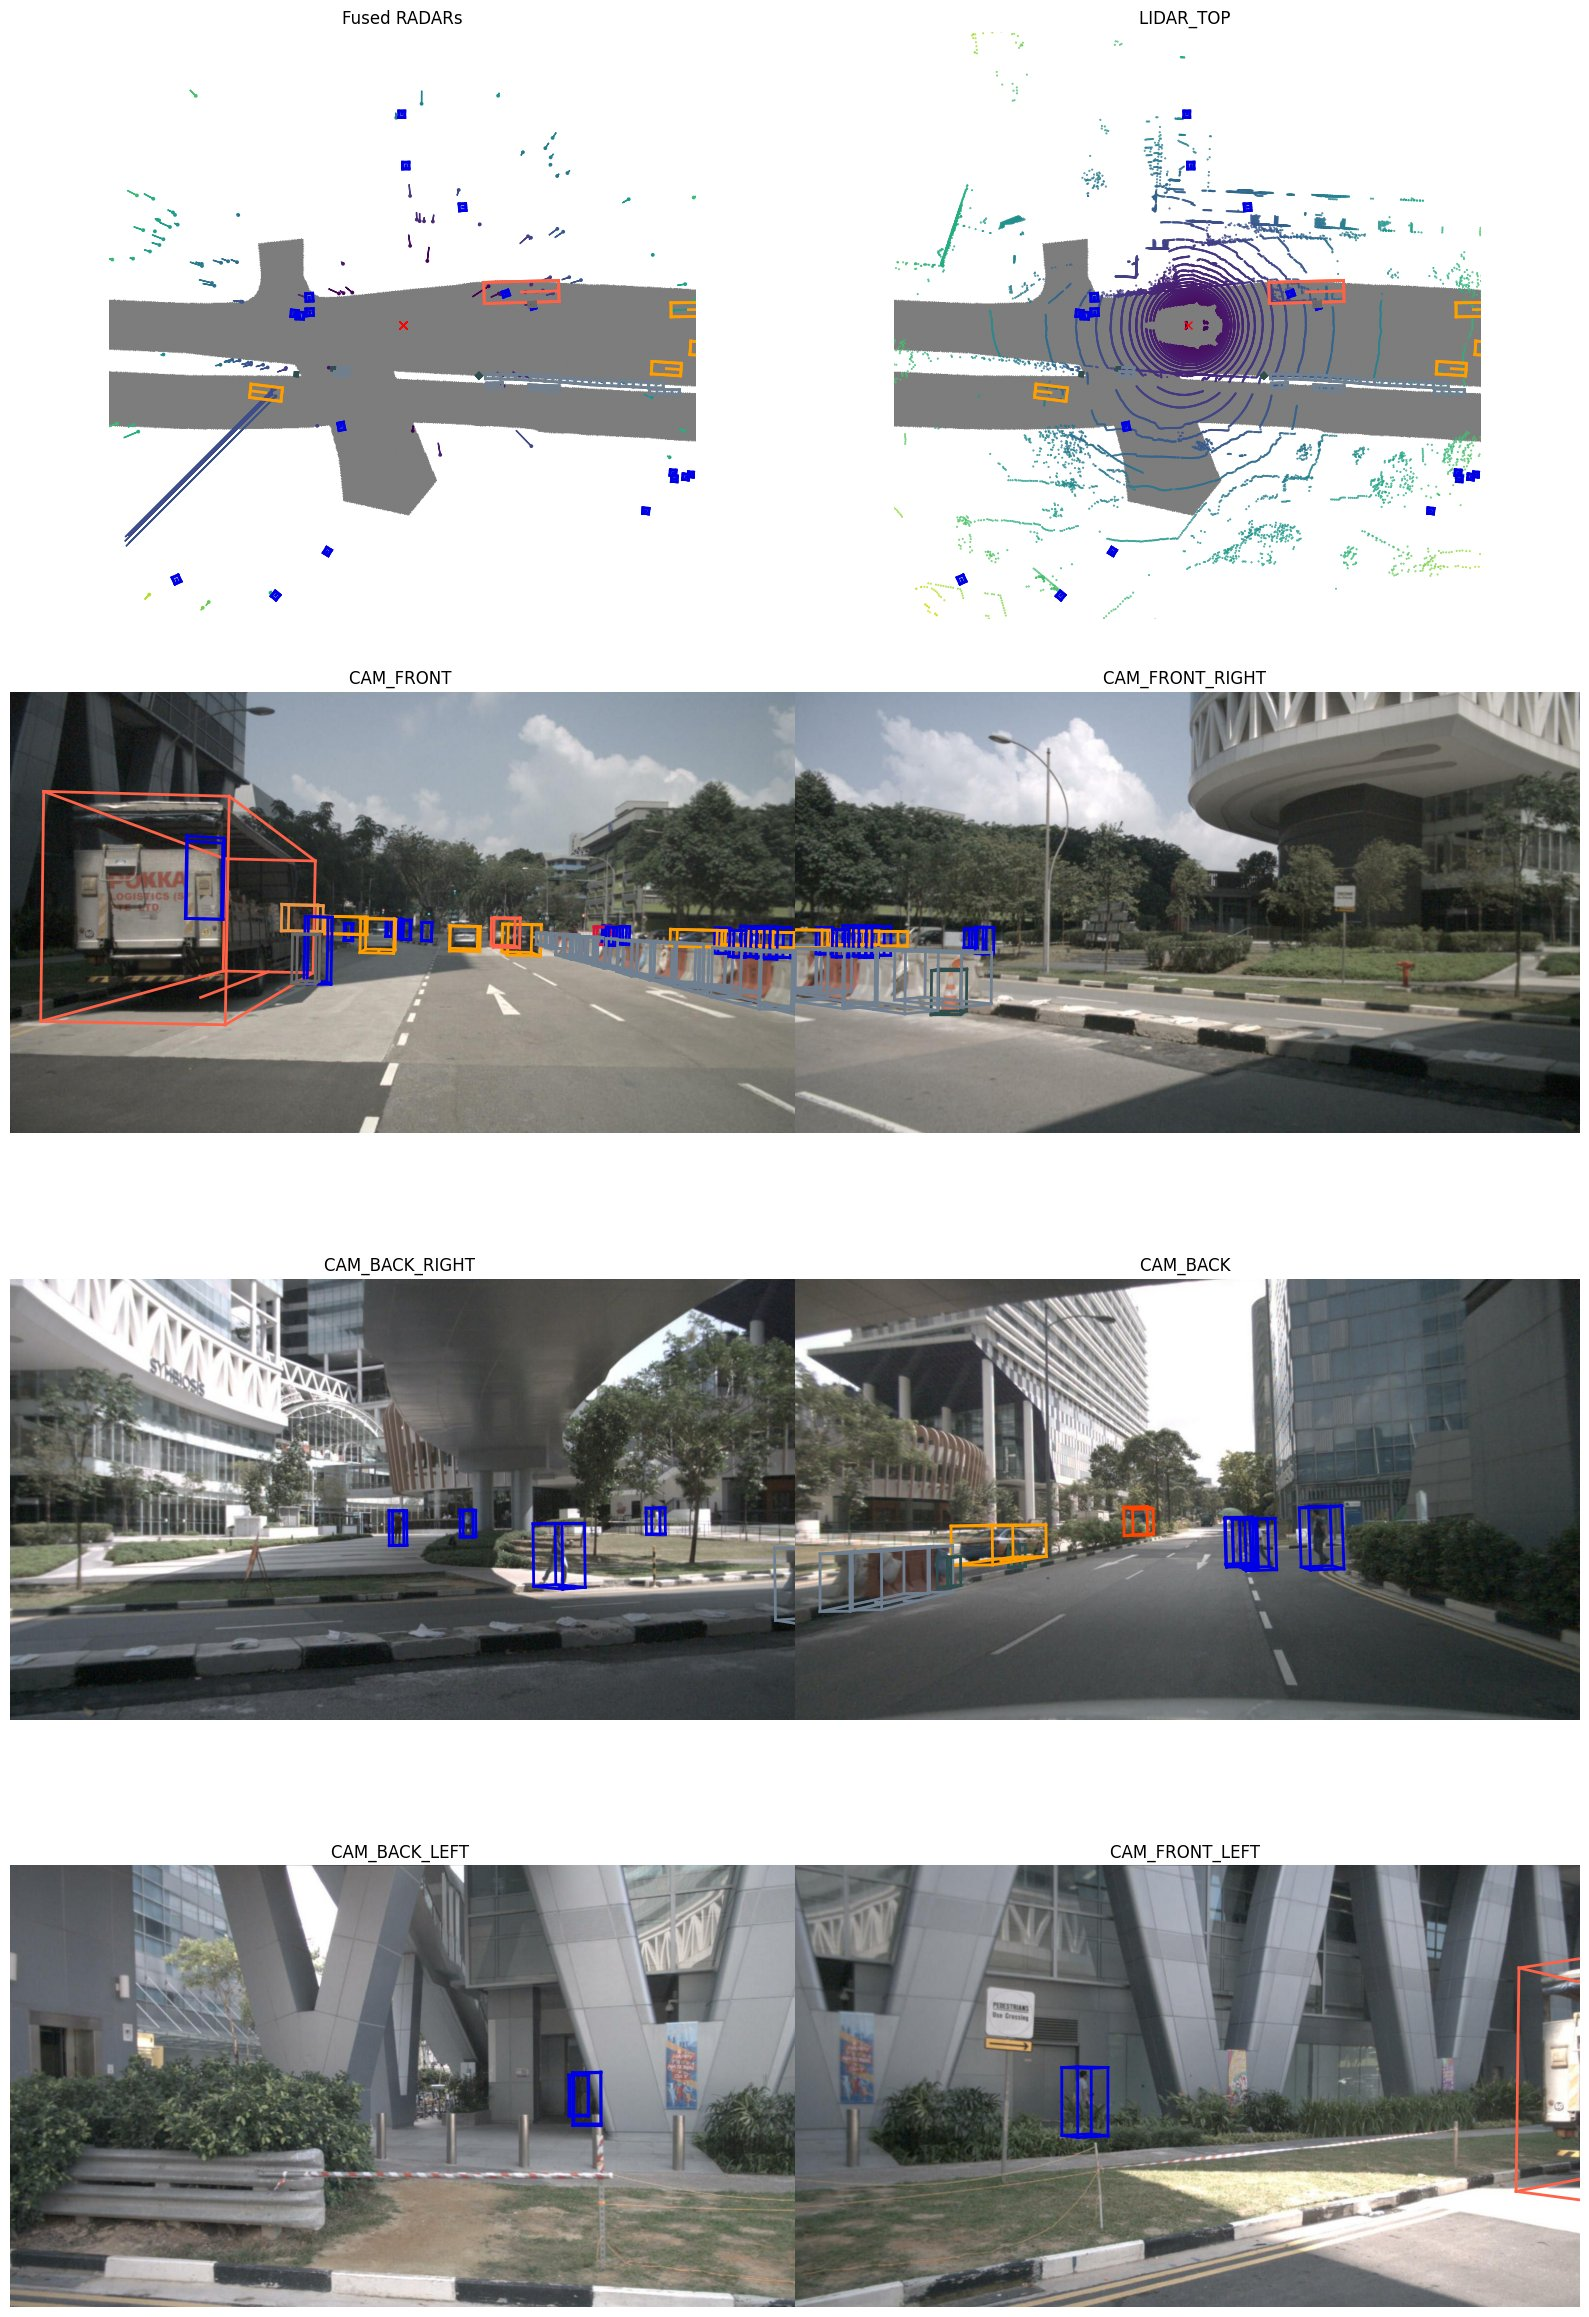

In [6]:
from nuscenes.nuscenes import NuScenes
import matplotlib.pyplot as plt

print("Loading nuScenes dataset...")
nusc = NuScenes(version='v1.0-mini', dataroot='./data/sets/nuscenes', verbose=False)

# Grab the very first frame in the dataset
my_sample = nusc.sample[0]
sample_token = my_sample['token']

print("Rendering actual Bird's-Eye View and Camera feeds...")
fig, axes = plt.subplots(1, 1, figsize=(16, 9))
nusc.render_sample(sample_token, out_path='real_bev_ground_truth.png')



## 7 · Geometry: frustum → ego coordinates with real calibration

For every (pixel, depth-bin) pair: `x_cam = (u − cx)·d / fx`, `y_cam = (v − cy)·d / fy`, `z_cam = d`, then `p_ego = R·p_cam + t` with the
camera's calibrated rotation (quaternion → matrix) and translation. The intrinsics are rescaled from 1600×900 to the 448×224 network input.

In [7]:
import torch
import torch.nn as nn

class GeometryGenerator(nn.Module):
    def __init__(self, feature_size=(16, 32), img_size=(224, 448), depth_bounds=(4.0, 45.0, 1.0)):
        super().__init__()
        self.feature_size = feature_size
        self.img_size = img_size
        self.depth_bounds = depth_bounds

        # 1. Create a 3D grid in image-space: (Depth, Height, Width)
        # We need the pixel coordinates (u, v) corresponding to our 16x32 feature map
        # scaled back up to the original 224x448 image resolution.
        xs = torch.linspace(0, img_size[1] - 1, feature_size[1], dtype=torch.float32)
        ys = torch.linspace(0, img_size[0] - 1, feature_size[0], dtype=torch.float32)
        
        # Create the discrete depth bins (e.g., 4m to 45m in 1m increments = 41 bins)
        ds = torch.arange(depth_bounds[0], depth_bounds[1], depth_bounds[2], dtype=torch.float32)
        
        # Generate the meshgrid
        zs, ys, xs = torch.meshgrid(ds, ys, xs, indexing='ij')
        
        # Stack into shape: [Depth_Bins, Feat_H, Feat_W, 3] where the last dim is (x, y, depth)
        frustum = torch.stack([xs, ys, zs], dim=-1)
        
        # Register as a PyTorch buffer so it automatically moves to the GPU, 
        # but isn't treated as a learnable weight.
        self.register_buffer('frustum', frustum)

    def forward(self, intrinsics, extrinsics_rot, extrinsics_trans):
        """
        intrinsics: [Batch, N_Cams, 3, 3]
        extrinsics_rot: [Batch, N_Cams, 3, 3]
        extrinsics_trans: [Batch, N_Cams, 3]
        """
        B, N, _, _ = intrinsics.shape
        D, H, W, _ = self.frustum.shape

        # Create a batched version of our base image-space frustum
        # Shape: [B, N, D, H, W, 3]
        points = self.frustum.unsqueeze(0).unsqueeze(0).expand(B, N, D, H, W, 3)

        # Separate into image (u,v) coordinates and depth (d)
        u = points[..., 0] # X pixel
        v = points[..., 1] # Y pixel
        d = points[..., 2] # Depth

        # --- STEP 1: Image Space to Camera 3D Space (Unprojection) ---
        # Pull focal lengths (fx, fy) and optical centers (cx, cy) from the intrinsics matrix
        fx = intrinsics[..., 0, 0].view(B, N, 1, 1, 1)
        fy = intrinsics[..., 1, 1].view(B, N, 1, 1, 1)
        cx = intrinsics[..., 0, 2].view(B, N, 1, 1, 1)
        cy = intrinsics[..., 1, 2].view(B, N, 1, 1, 1)

        # Formula: x_cam = (u - cx) * depth / fx
        x_cam = (u - cx) * d / fx
        y_cam = (v - cy) * d / fy
        z_cam = d

        # Stack into Camera 3D coordinates: [B, N, D, H, W, 3]
        cam_points = torch.stack([x_cam, y_cam, z_cam], dim=-1)

        # --- STEP 2: Camera 3D Space to Ego Vehicle 3D Space ---
        # Multiply by Rotation matrix and add Translation vector
        # cam_points shape: [B, N, D*H*W, 3]
        cam_points_flat = cam_points.view(B, N, -1, 3)
        
        # Matrix Multiplication: (Rotation * Points^T)^T
        ego_points_flat = torch.matmul(extrinsics_rot, cam_points_flat.transpose(2, 3)).transpose(2, 3)
        
        # Add translation: [B, N, 1, 3]
        ego_points_flat = ego_points_flat + extrinsics_trans.unsqueeze(2)

        # Reshape back to [Batch, N_Cams, Depth, Height, Width, 3]
        ego_points = ego_points_flat.view(B, N, D, H, W, 3)

        return ego_points

if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    geom_net = GeometryGenerator().to(device)
    
    B, N_Cams = 2, 6
    
    # 1. Simulate dummy Intrinsic matrices (3x3 focal lengths/optical centers)
    dummy_intrinsics = torch.eye(3).view(1, 1, 3, 3).expand(B, N_Cams, 3, 3).to(device)
    
    # 2. Simulate dummy Extrinsic Rotation matrices (3x3 camera angles)
    dummy_rot = torch.eye(3).view(1, 1, 3, 3).expand(B, N_Cams, 3, 3).to(device)
    
    # 3. Simulate dummy Extrinsic Translation vectors (3D (X,Y,Z) mounting positions)
    dummy_trans = torch.zeros(B, N_Cams, 3).to(device)
    
    ego_coords = geom_net(dummy_intrinsics, dummy_rot, dummy_trans)
    
    print(f"Ego 3D Coordinates Shape: {ego_coords.shape}")
    print("Format Breakdown: [Batch, Cameras, Depth_Bins, Feat_Height, Feat_Width, 3_XYZ]")

Ego 3D Coordinates Shape: torch.Size([2, 6, 41, 16, 32, 3])
Format Breakdown: [Batch, Cameras, Depth_Bins, Feat_Height, Feat_Width, 3_XYZ]


## 8 · End-to-end forward pass with real nuScenes calibration

Loading nuScenes Dataset...
Fetching real multi-camera data and calibrations...
Initializing Master Model...
Initializing End-to-End BEV Network...
Loading pre-trained foundation model: dinov2_vits14...


Running forward pass with REAL spatial geometry...
Semantic Occupancy Map: torch.Size([2, 3, 200, 200])
3D Detection Heatmap:   torch.Size([2, 8, 200, 200])


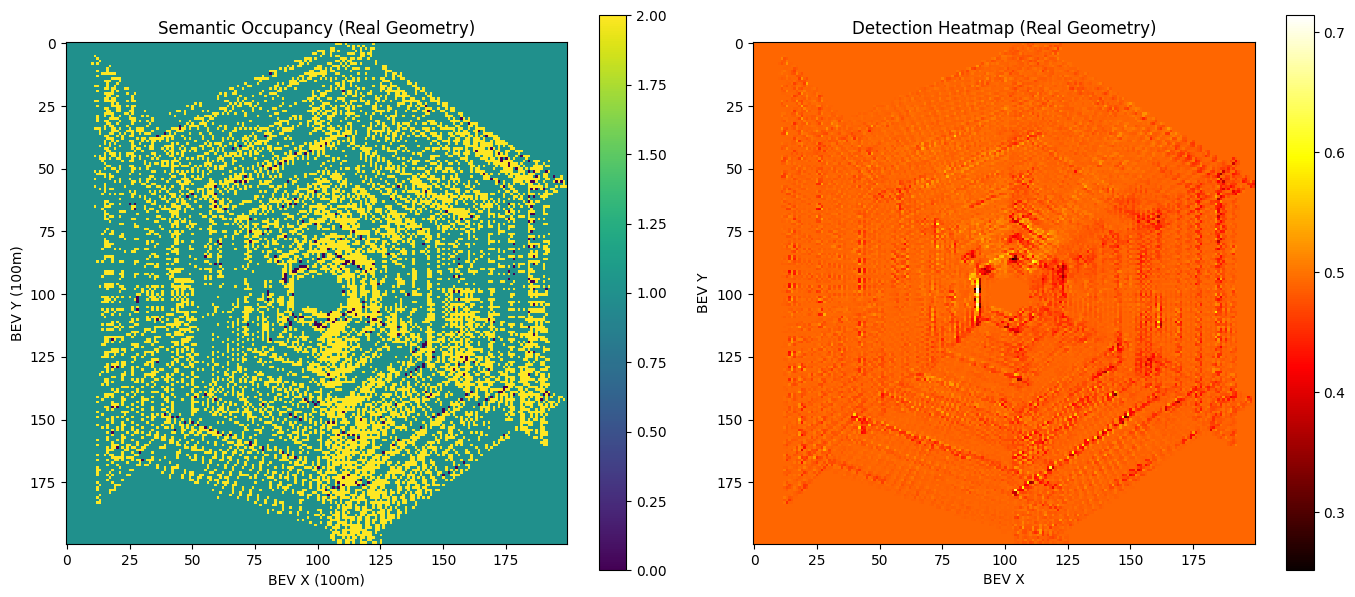

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
from nuscenes.nuscenes import NuScenes
from pyquaternion import Quaternion

# [1] UPGRADED DATASET: Now extracts REAL camera calibrations and scales them
class NuScenesMultiCamDataset(Dataset):
    def __init__(self, nusc, transform=None):
        self.nusc = nusc
        self.samples = self.nusc.sample
        self.cams = [
            'CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT',
            'CAM_BACK_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT'
        ]
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 448)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        imgs, intrinsics, extrinsics_rot, extrinsics_trans = [], [], [], []

        for cam in self.cams:
            cam_data = self.nusc.get('sample_data', sample['data'][cam])
            img_path = os.path.join(self.nusc.dataroot, cam_data['filename'])

            # 1. Load and Transform Image
            img = Image.open(img_path).convert('RGB')
            img = self.transform(img)
            imgs.append(img)

            # 2. Extract Real Calibrations (FIXED: using 'calibrated_sensor_token')
            cs_record = self.nusc.get('calibrated_sensor', cam_data['calibrated_sensor_token'])

            # Intrinsics: Scale them because we resized the image from 1600x900 to 448x224
            scale_x = 448.0 / 1600.0
            scale_y = 224.0 / 900.0
            
            intrinsic_tensor = torch.tensor(cs_record['camera_intrinsic'], dtype=torch.float32)
            intrinsic_tensor[0, 0] *= scale_x  # fx (focal length X)
            intrinsic_tensor[0, 2] *= scale_x  # cx (optical center X)
            intrinsic_tensor[1, 1] *= scale_y  # fy (focal length Y)
            intrinsic_tensor[1, 2] *= scale_y  # cy (optical center Y)
            intrinsics.append(intrinsic_tensor)

            # Extrinsics: Convert quaternion to 3x3 rotation matrix
            rot_matrix = Quaternion(cs_record['rotation']).rotation_matrix
            extrinsics_rot.append(torch.tensor(rot_matrix, dtype=torch.float32))
            
            # Extrinsics: Translation vector
            extrinsics_trans.append(torch.tensor(cs_record['translation'], dtype=torch.float32))

        return (
            torch.stack(imgs, dim=0),
            torch.stack(intrinsics, dim=0),
            torch.stack(extrinsics_rot, dim=0),
            torch.stack(extrinsics_trans, dim=0)
        )

# [2] THE MASTER NETWORK: Wires the modules previously defined in your notebook
class BEVNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        print("Initializing End-to-End BEV Network...")
        self.backbone = MultiCamDINOv2Backbone()
        self.lift = LiftModule(in_channels=384, out_channels=64, depth_bins=41)
        self.geometry = GeometryGenerator(feature_size=(16, 32), img_size=(224, 448))
        self.splat = SplatModule(bev_resolution=0.5, bev_size=(200, 200), feature_channels=64)
        self.heads = BEVTaskHeads(in_channels=64, num_semantic_classes=3, num_det_classes=1)

    def forward(self, images, intrinsics, extrinsics_rot, extrinsics_trans):
        features = self.backbone(images)
        frustum3d = self.lift(features)
        ego_coords = self.geometry(intrinsics, extrinsics_rot, extrinsics_trans)
        bev_grid = self.splat(frustum3d, ego_coords)
        semantic_map, detection_heatmap = self.heads(bev_grid)
        return semantic_map, detection_heatmap

# [3] END-TO-END EXECUTION
if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    print("Loading nuScenes Dataset...")
    nusc = NuScenes(version='v1.0-mini', dataroot='./data/sets/nuscenes', verbose=False)
    dataset = NuScenesMultiCamDataset(nusc)
    dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

    print("Fetching real multi-camera data and calibrations...")
    batch_imgs, batch_intrinsics, batch_ext_rot, batch_ext_trans = next(iter(dataloader))

    batch_imgs = batch_imgs.to(device)
    batch_intrinsics = batch_intrinsics.to(device)
    batch_ext_rot = batch_ext_rot.to(device)
    batch_ext_trans = batch_ext_trans.to(device)

    print("Initializing Master Model...")
    model = BEVNetwork().to(device)
    model.eval() 

    print("Running forward pass with REAL spatial geometry...")
    with torch.no_grad():
        semantic_out, detection_out = model(batch_imgs, batch_intrinsics, batch_ext_rot, batch_ext_trans)

    print(f"Semantic Occupancy Map: {semantic_out.shape}")
    print(f"3D Detection Heatmap:   {detection_out.shape}")

    # Render inline visualization
    semantic_grid = torch.argmax(semantic_out[0].cpu(), dim=0).numpy()
    objectness_score = torch.sigmoid(detection_out[0, 0].cpu()).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im1 = axes[0].imshow(semantic_grid, cmap='viridis', interpolation='nearest')
    axes[0].set_title('Semantic Occupancy (Real Geometry)')
    axes[0].set_xlabel('BEV X (100m)')
    axes[0].set_ylabel('BEV Y (100m)')
    fig.colorbar(im1, ax=axes[0])

    im2 = axes[1].imshow(objectness_score, cmap='hot', interpolation='nearest')
    axes[1].set_title('Detection Heatmap (Real Geometry)')
    axes[1].set_xlabel('BEV X')
    axes[1].set_ylabel('BEV Y')
    fig.colorbar(im2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()

**Reading the output.** With real calibration, the occupied region forms a **hexagon of six camera frustums** around the ego vehicle. There is a
hole in the centre (nothing is closer than 4 m, the first depth bin), and the corners of the 100 m grid stay empty because depth stops at 45 m.
The camera geometry is therefore correct. The values inside are meaningless because the heads are untrained.

## 9 · Roadmap to a trained model

1. **Targets.** Rasterise nuScenes drivable-area / lane polygons from the map API and 3-D box centres into the 200×200 BEV grid.
2. **Loss and training.** Cross-entropy for occupancy and focal loss plus L1 for the CenterPoint-style heads. Freeze DINOv2 at first, then fine-tune the last blocks.
3. **Speed.** Replace the Python loop in `SplatModule` with a batched `scatter_add_` or the LSS cumsum trick, and precompute the geometry per camera rig.
4. **Metrics.** BEV IoU for drivable area, nuScenes mAP / NDS for detection, on the v1.0-trainval split.